------------------
```markdown
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amendments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com
```
------------------------------
❗❗❗ **IMPORTANT**❗❗❗ **Create a copy of this notebook**

In order to work with this Google Colab you need to create a copy of it. Please **DO NOT** provide your answers here. Instead, work on the copy version. To make a copy:

**Click on: File -> save a copy in drive**

Have you successfully created the copy? if yes, there must be a new tab opened in your browser. Now move to the copy and start from there!

----------------------------------------------


# Agent-Based Modeling I: Schelling Segregation Model

## Learning Objectives

By the end of this notebook, you will be able to:
1. Understand the ODD (Overview, Design concepts, Details) protocol for ABMs
2. Implement a basic agent-based model from scratch in Python
3. Visualize agent behavior and emergent patterns
4. Analyze how micro-level rules lead to macro-level outcomes
5. Explore the Schelling segregation model and its implications

# Agent-Based Modeling (ABM): Schelling Segregation Model

In this notebook, we walk through the steps of designing a simple Agend-based Model (ABM). For the sake of clarity, we choose a simple yet rich model to convey the fundamental concepts, namely, Schelling Segregation Model.

## Overview, Design Concepts, & Details (ODD)
Throughout the whole modeling process, we respect the ODD protocol introduced by Railsback and Grimm in their book called "Agent-based and Individual-based Modeling: A Practical Introduction".

### Overview
The overview step of ODD consists of several elements that are introduced in the following subsection.

#### Purpose

We would like to model residential segregation patterns to understand whether strong segregation can emerge from mild individual preferences for same-type neighbors. Specifically, we want to answer: **Can moderate tolerance thresholds at the individual level produce high levels of segregation at the population level?**

This model addresses the puzzle of persistent urban segregation despite relatively weak expressed preferences for neighborhood composition.

#### Entities, State Variables, & Scales

**Entities**:
- **Agents**: Individual households (two types: blue and red)
- **Environment**: 2D grid representing residential space (patches/cells)

In [54]:
class Agent:
    """Represents an agent (resident) in the Schelling segregation model."""

In [55]:
class Environment:
    """Represents the grid environment for the Schelling segregation model."""

**State Variables**:
- **Agent-level**:
  - `type`: Group membership (0=blue, 1=red)
  - `x, y`: Grid coordinates (location)
  - `tolerance`: Minimum fraction of similar neighbors required for happiness (0 to 1)
  - `happy`: Boolean indicating satisfaction with current location
  
- **Environment-level**:
  - `grid`: 2D array tracking occupancy (0=empty, agent_id=occupied)
  - `segregation_index`: Global measure of spatial segregation

**Scales**:
- **Spatial**: 50×50 grid (can be varied), each cell represents one residential location
- **Temporal**: One time step = one round where all unhappy agents have opportunity to move
- **Simulation duration**: Run until convergence (no unhappy agents) or maximum 100 steps

In [56]:
class Agent:
    """
    Represents an agent (resident) in the Schelling segregation model.

    Agents have a type (e.g., red or blue) and a preference for living near
    similar agents. They move if their neighborhood doesn't meet their
    similarity threshold.

    Attributes:
        x (int): The x-coordinate of the agent's position.
        y (int): The y-coordinate of the agent's position.
        agent_type (int): Type identifier (1 or 2).
        similarity_threshold (float): Minimum fraction of similar neighbors desired (0-1).
    """

    def __init__(self, x, y, agent_type, similarity_threshold=0.3):
        """
        Initialize an agent with position, type, and preferences.

        Args:
            x (int): Initial x-coordinate (0 to GRID_SIZE-1).
            y (int): Initial y-coordinate (0 to GRID_SIZE-1).
            agent_type (int): Agent type (AGENT_TYPE_A or AGENT_TYPE_B).
            similarity_threshold (float): Desired fraction of similar neighbors (0-1).
        """
        self.x = x
        self.y = y
        self.agent_type = agent_type
        self.similarity_threshold = similarity_threshold

In [57]:
class Environment:
    """
    Represents the grid environment for the Schelling segregation model.

    The environment is a 2D grid where each cell can be empty or contain
    an agent of a specific type. Tracks agent positions and provides
    methods for agent movement.

    Attributes:
        grid (np.ndarray): 2D array representing the grid (GRID_SIZE x GRID_SIZE).
                          Values: 0=empty, 1=type A, 2=type B
    """

    def __init__(self):
        """Initialize an empty grid."""
        self.grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)

#### Process Overview and Scheduling

**Each time step consists of:**

1. **Assessment phase**: Each agent evaluates happiness
   - Count similar neighbors in Moore neighborhood (8 adjacent cells)
   - If fraction of similar neighbors ≥ tolerance → happy
   - Else → unhappy

In [58]:
class Agent:
    """
    Represents an agent (resident) in the Schelling segregation model.

    Agents have a type (e.g., red or blue) and a preference for living near
    similar agents. They move if their neighborhood doesn't meet their
    similarity threshold.

    Attributes:
        x (int): The x-coordinate of the agent's position.
        y (int): The y-coordinate of the agent's position.
        agent_type (int): Type identifier (1 or 2).
        similarity_threshold (float): Minimum fraction of similar neighbors desired (0-1).
    """

    def __init__(self, x, y, agent_type, similarity_threshold=0.3, neighborhood_radius=1):
        """
        Initialize an agent with position, type, and preferences.

        Args:
            x (int): Initial x-coordinate (0 to GRID_SIZE-1).
            y (int): Initial y-coordinate (0 to GRID_SIZE-1).
            agent_type (int): Agent type (AGENT_TYPE_A or AGENT_TYPE_B).
            similarity_threshold (float): Desired fraction of similar neighbors (0-1).
        """
        self.x = x
        self.y = y
        self.agent_type = agent_type
        self.similarity_threshold = similarity_threshold
        self.neighborhood_radius = neighborhood_radius

    def is_happy(self, env):
        """
        Check if agent is satisfied with current neighborhood composition.

        An agent is happy if the fraction of similar neighbors meets or exceeds
        their similarity threshold. Empty cells are ignored in the calculation.

        Args:
            env (Environment): The environment containing the grid.

        Returns:
            bool: True if agent is happy, False otherwise.
        """
        neighbor_positions = self.get_neighbor_positions()

        similar_count = 0
        total_count = 0

        for nx, ny in neighbor_positions:
            neighbor_type = env.grid[nx, ny]

            # Skip empty cells
            if neighbor_type == 0:
                continue

            total_count += 1
            if neighbor_type == self.agent_type:
                similar_count += 1

        # If no neighbors, agent is unhappy (isolated)
        if total_count == 0:
            return False

        # Calculate similarity fraction
        similarity = similar_count / total_count

        return similarity >= self.similarity_threshold

    def get_neighbor_positions(self):
        """
        Get positions of Moore neighborhood (8 adjacent cells).

        Returns:
            list: List
        """
        positions = []
        for dx in range(-self.neighborhood_radius, self.neighborhood_radius + 1):
            for dy in range(-self.neighborhood_radius, self.neighborhood_radius + 1):
                if dx == 0 and dy == 0:
                    continue
                nx = (self.x + dx) % GRID_SIZE
                ny = (self.y + dy) % GRID_SIZE
                positions.append((nx, ny))
        return positions

2. **Movement phase**: Unhappy agents relocate
   - For each unhappy agent (in random order):
     - Select random empty cell
     - Move to that location
     - Update grid

In [59]:
class Environment:
    """
    Represents the grid environment for the Schelling segregation model.

    The environment is a 2D grid where each cell can be empty or contain
    an agent of a specific type. Tracks agent positions and provides
    methods for agent movement.

    Attributes:
        grid (np.ndarray): 2D array representing the grid (GRID_SIZE x GRID_SIZE).
                          Values: 0=empty, 1=type A, 2=type B
    """

    def __init__(self, grid_size=50):
        """Initialize an empty grid."""
        self.grid = np.zeros((grid_size, grid_size), dtype=int)
        self.grid_size = grid_size

    def get_empty_cells(self):
        """
        Get list of all empty cell coordinates.

        Returns:
            list: List of (x, y) tuples for empty cells.
        """
        empty_cells = []
        for x in range(self.grid_size):
            for y in range(self.grid_size):
                if self.grid[x, y] == EMPTY_CELL:
                    empty_cells.append((x, y))
        return empty_cells

    def place_agent(self, agent, x, y):
        """
        Place an agent at specified coordinates.

        Args:
            agent (Agent): The agent to place.
            x (int): X-coordinate.
            y (int): Y-coordinate.

        Raises:
            ValueError: If cell is already occupied.
        """
        if self.grid[x, y] != EMPTY_CELL:
            raise ValueError(f"Cell ({x}, {y}) is already occupied")

        self.grid[x, y] = agent.agent_type
        agent.x = x
        agent.y = y

    def remove_agent(self, agent):
        """
        Remove an agent from the grid.

        Args:
            agent (Agent): The agent to remove.
        """
        self.grid[agent.x, agent.y] = EMPTY_CELL

    def move_agent(self, agent, new_x, new_y):
        """
        Move an agent to a new location.

        Args:
            agent (Agent): The agent to move.
            new_x (int): New x-coordinate.
            new_y (int): New y-coordinate.

        Raises:
            ValueError: If destination cell is occupied.
        """
        if self.grid[new_x, new_y] != EMPTY_CELL:
            raise ValueError(f"Cannot move to occupied cell ({new_x}, {new_y})")

        # Remove from old position
        self.grid[agent.x, agent.y] = EMPTY_CELL

        # Place at new position
        self.grid[new_x, new_y] = agent.agent_type
        agent.x = new_x
        agent.y = new_y

    def count_neighbors(self, x, y, radius=1):
        """
        Count neighbors of each type around a position.

        Args:
            x (int): X-coordinate of center position.
            y (int): Y-coordinate of center position.
            radius (int): Neighborhood radius (default 1 = Moore neighborhood).

        Returns:
            dict: Dictionary with counts {'type_a': int, 'type_b': int, 'empty': int}
        """
        counts = {'type_a': 0, 'type_b': 0, 'empty': 0}

        for dx in range(-radius, radius + 1):
            for dy in range(-radius, radius + 1):
                # Skip center
                if dx == 0 and dy == 0:
                    continue

                # Handle wrapping
                nx = (x + dx) % GRID_SIZE
                ny = (y + dy) % GRID_SIZE

                cell_value = self.grid[nx, ny]

                if cell_value == EMPTY_CELL:
                    counts['empty'] += 1
                elif cell_value == AGENT_TYPE_A:
                    counts['type_a'] += 1
                elif cell_value == AGENT_TYPE_B:
                    counts['type_b'] += 1

        return counts

    def get_occupancy_rate(self):
        """
        Calculate fraction of grid that is occupied.

        Returns:
            float: Occupancy rate (0-1).
        """
        occupied = np.sum(self.grid != EMPTY_CELL)
        total = GRID_SIZE * GRID_SIZE
        return occupied / total

3. **Measurement phase**:
   - Calculate fraction of happy agents
   - Compute global segregation index
   - Record metrics

In [60]:
# Metrics to track:
def calculate_happiness_rate(agents, env):
    """Fraction of happy agents."""
    happy = sum(1 for agent in agents if agent.is_happy(env))
    return happy / len(agents) if agents else 0

def calculate_segregation_index(grid):
    """Average neighbor similarity across all agents."""
    similarities = []
    for x in range(GRID_SIZE):
        for y in range(GRID_SIZE):
            if grid[x, y] == EMPTY_CELL:
                continue
            agent_type = grid[x, y]
            similar, total = 0, 0
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    if dx == 0 and dy == 0:
                        continue
                    nx, ny = (x + dx) % GRID_SIZE, (y + dy) % GRID_SIZE
                    if grid[nx, ny] != EMPTY_CELL:
                        total += 1
                        if grid[nx, ny] == agent_type:
                            similar += 1
            if total > 0:
                similarities.append(similar / total)
    return np.mean(similarities) if similarities else 0

4. **Stopping condition**:
   - Stop if all agents happy OR max steps reached

**Scheduling**: Asynchronous updating (agents move one at a time in random order within each time step)

In [61]:
def run(self, max_steps=100):
    """Run until convergence."""
    for step in range(max_steps):
        moves = self.step()
        if moves == 0:
            print(f"Converged at step {step}")
            return step
    print(f"Reached max steps ({max_steps})")
    return max_steps

### Design Concepts

**Emergence**: Strong residential segregation emerges from mild individual tolerance thresholds. Even when agents are satisfied with 30% same-type neighbors, the system converges to ~80-90% segregation.

**Adaptation**: Agents adaptively relocate when their neighborhood composition falls below their tolerance threshold.

In [62]:
def step(self):
        """Execute one timestep."""
        import random
        random.shuffle(self.agents)
        moves = 0
        for agent in self.agents:
            if not agent.is_happy(self.env):
                empty = self.env.get_empty_cells()
                if empty:
                    new_x, new_y = random.choice(empty)
                    self.env.move_agent(agent, new_x, new_y)
                    moves += 1
        self.timestep += 1
        self.history['happiness'].append(calculate_happiness_rate(self.agents, self.env))
        self.history['segregation'].append(calculate_segregation_index(self.env.grid))
        return moves

**Objectives**: Each agent seeks to live in a location where the fraction of similar neighbors meets or exceeds their tolerance threshold.

**Sensing**: Agents have perfect, local information about their Moore neighborhood (8 adjacent cells). They do not know global segregation levels.

In [63]:
def get_empty_cells(self):
        """
        Get list of all empty cell coordinates.

        Returns:
            list: List of (x, y) tuples for empty cells.
        """
        empty_cells = []
        for x in range(GRID_SIZE):
            for y in range(GRID_SIZE):
                if self.grid[x, y] == EMPTY_CELL:
                    empty_cells.append((x, y))
        return empty_cells

**Interaction**: Indirect interaction through spatial competition. When agents move, they change neighborhood composition for others, creating cascading dynamics.

**Stochasticity**:
- Initial agent placement is random
- Order of agent moves is randomized each step
- Destination for unhappy agents is selected randomly from empty cells

In [64]:
def place_agent(self, agent, x, y):
        """
        Place an agent at specified coordinates.

        Args:
            agent (Agent): The agent to place.
            x (int): X-coordinate.
            y (int): Y-coordinate.

        Raises:
            ValueError: If cell is already occupied.
        """
        if self.grid[x, y] != EMPTY_CELL:
            raise ValueError(f"Cell ({x}, {y}) is already occupied")

        self.grid[x, y] = agent.agent_type
        agent.x = x
        agent.y = y

**Collectives**: No explicit collectives (agents are independent households).

**Observation**: Track fraction of happy agents, global segregation index (average fraction of same-type neighbors), and spatial clustering patterns over time.

In [65]:
# Metrics to track:
def calculate_happiness_rate(agents, env):
    """Fraction of happy agents."""
    happy = sum(1 for agent in agents if agent.is_happy(env))
    return happy / len(agents) if agents else 0

def calculate_segregation_index(grid):
    """Average neighbor similarity across all agents."""
    similarities = []
    for x in range(GRID_SIZE):
        for y in range(GRID_SIZE):
            if grid[x, y] == EMPTY_CELL:
                continue
            agent_type = grid[x, y]
            similar, total = 0, 0
            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    if dx == 0 and dy == 0:
                        continue
                    nx, ny = (x + dx) % GRID_SIZE, (y + dy) % GRID_SIZE
                    if grid[nx, ny] != EMPTY_CELL:
                        total += 1
                        if grid[nx, ny] == agent_type:
                            similar += 1
            if total > 0:
                similarities.append(similar / total)
    return np.mean(similarities) if similarities else 0

## Running the model

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import ListedColormap
from IPython.display import HTML
import seaborn as sns
from typing import List, Tuple

# Set random seed for reproducibility
np.random.seed(42)

We use the following configuration for our model:

In [67]:
# Code# Configuration
"""Configuration for Schelling segregation model."""

# Grid dimensions
GRID_SIZE = 50

# Agent variables
AGENT_TYPE_A = 1  # Red agents
AGENT_TYPE_B = 2  # Blue agents
EMPTY_CELL = 0

# Neighborhood
NEIGHBORHOOD_RADIUS = 1  # Moore neighborhood (8 neighbors)

# Similarity preferences
DEFAULT_SIMILARITY_THRESHOLD = 0.3  # Want 30%+ similar neighbors

# Visualization colors
COLOR_EMPTY = '#FFFFFF'     # White
COLOR_TYPE_A = '#FF6B6B'    # Red
COLOR_TYPE_B = '#4ECDC4'    # Blue
COLOR_UNHAPPY = '#FFD93D'   # Yellow (for highlighting)

We can also define a class that would determine how state parameters

In [68]:
# Create model class
class SchellingModel:
    """Complete Schelling segregation model."""

    def __init__(self, n_agents=2000, occupancy=0.8, similarity_threshold=DEFAULT_SIMILARITY_THRESHOLD,
    neighborhod_radius=NEIGHBORHOOD_RADIUS):
        self.similarity_threshold = similarity_threshold
        self.neighborhood_radius = neighborhod_radius
        self.env = Environment()
        self.n_agents = min(n_agents, int(self.env.grid_size**2*occupancy))
        self.agents = []
        self.timestep = 0
        self.history = {'happiness': [], 'segregation': []}
        self._initialize_agents()

    def _initialize_agents(self):
        """Place agents randomly on grid."""
        import random
        positions = [(x, y) for x in range(self.env.grid_size) for y in range(self.env.grid_size)]
        random.shuffle(positions)
        for i in range(self.n_agents):
            x, y = positions[i]
            agent_type = AGENT_TYPE_A if i < self.n_agents // 2 else AGENT_TYPE_B
            agent = Agent(x, y, agent_type, self.similarity_threshold)
            self.env.place_agent(agent, x, y)
            self.agents.append(agent)

    def step(self):
        """Execute one timestep."""
        import random
        random.shuffle(self.agents)
        moves = 0
        for agent in self.agents:
            if not agent.is_happy(self.env):
                empty = self.env.get_empty_cells()
                if empty:
                    new_x, new_y = random.choice(empty)
                    self.env.move_agent(agent, new_x, new_y)
                    moves += 1
        self.timestep += 1
        self.history['happiness'].append(calculate_happiness_rate(self.agents, self.env))
        self.history['segregation'].append(calculate_segregation_index(self.env.grid))
        return moves

    def run(self, max_steps=100):
        """Run until convergence."""
        for step in range(max_steps):
            moves = self.step()
            if moves == 0:
                print(f"Converged at step {step}")
                return step
        print(f"Reached max steps ({max_steps})")
        return max_steps

# Visualization function
def plot_grid(model, title=""):
    """Visualize grid state."""
    from matplotlib.colors import ListedColormap
    colors = [COLOR_EMPTY, COLOR_TYPE_A, COLOR_TYPE_B]
    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(model.env.grid, cmap=cmap, vmin=0, vmax=2)

    happiness = model.history['happiness'][-1] if model.history['happiness'] else 0
    segregation = model.history['segregation'][-1] if model.history['segregation'] else 0
    ax.set_title(f"{title}\nStep {model.timestep} | Happiness: {happiness:.1%} | Segregation: {segregation:.1%}",
                 fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

    # Legend
    from matplotlib.patches import Patch
    legend = [Patch(facecolor=COLOR_EMPTY, label='Empty'),
              Patch(facecolor=COLOR_TYPE_A, label='Type A'),
              Patch(facecolor=COLOR_TYPE_B, label='Type B')]
    ax.legend(handles=legend, loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

def plot_metrics(model):
    """Plot happiness and segregation over time."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))
    steps = range(len(model.history['happiness']))

    ax1.plot(steps, model.history['happiness'], 'g-', linewidth=2)
    ax1.set_xlabel('Timestep')
    ax1.set_ylabel('Happiness Rate')
    ax1.set_title('Agent Happiness Over Time')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])

    ax2.plot(steps, model.history['segregation'], 'r-', linewidth=2)
    ax2.set_xlabel('Timestep')
    ax2.set_ylabel('Segregation Index')
    ax2.set_title('Segregation Over Time')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1])
    plt.tight_layout()
    plt.show()

We are now ready to run the model and see the outcome:

Creating Schelling model...
Initialized with 2000 agents


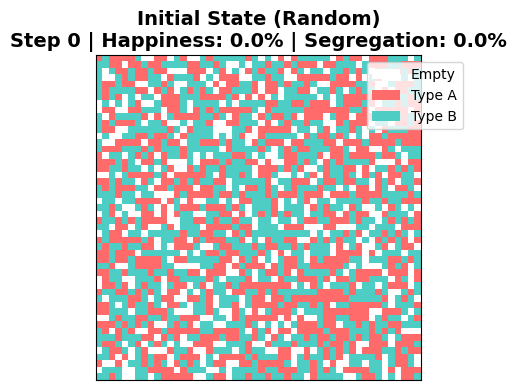


Running simulation...
Converged at step 14


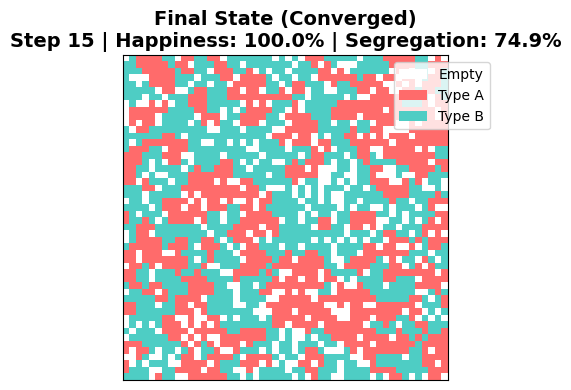

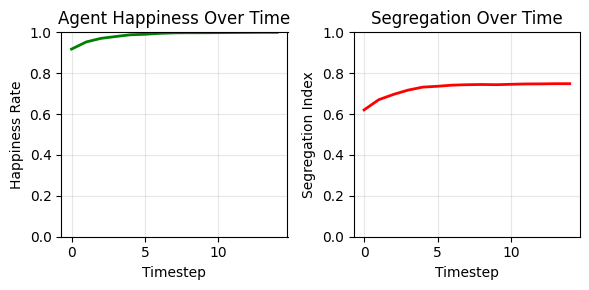


Final Results:
Happiness: 100.0%
Segregation: 74.9%


In [69]:
# RUN THE MODEL
print("Creating Schelling model...")
model = SchellingModel(n_agents=2200, occupancy=0.8, similarity_threshold=0.3)
print(f"Initialized with {len(model.agents)} agents")

# Show initial state
plot_grid(model, "Initial State (Random)")

# Run simulation
print("\nRunning simulation...")
model.run(max_steps=100)

# Show final state
plot_grid(model, "Final State (Converged)")

# Show metrics
plot_metrics(model)

print(f"\nFinal Results:")
print(f"Happiness: {model.history['happiness'][-1]:.1%}")
print(f"Segregation: {model.history['segregation'][-1]:.1%}")

## Key Insights

### Emergence in Action

The Schelling model demonstrates **strong emergence**: mild individual preferences produce dramatic system-level segregation.

**Key observations:**
1. **Non-obvious mapping**: 30% tolerance → ~75% segregation (not 30%!)
2. **Feedback dynamics**: As segregation increases, it becomes self-reinforcing
3. **Local → Global**: Agents using only local information create global patterns
4. **No central planning**: Segregation emerges without anyone intending it

### Policy Implications

- Observed segregation patterns may arise from **much milder** preferences than they suggest
- Small changes in tolerance can have **large effects** on segregation
- Interventions must account for **dynamic feedback** (not just static preferences)

### Model Limitations

This is a **minimal model**. Real segregation involves:
- Economic constraints (housing prices)
- Information asymmetries
- Social networks
- Historical path dependence
- Discrimination in housing markets

**Next steps**: Add complexity incrementally to test additional hypotheses

**Congratulations! You have finished the Notebook! Great Job!**
🤗🙌👍👏💪
<!--
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amandments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com.
-->